## Rydberg one-hot encoding through blockade mechanism for the Restricted $^{18}O$

#### Create the graph

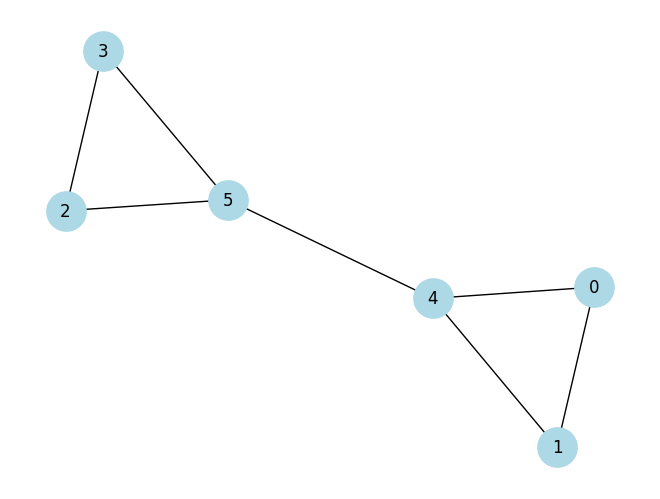

In [67]:
import numpy as np
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import networkx as nx
import matplotlib.pyplot as plt

from src.utils import computational_basis

physical_qubits = 6
nqubits = 4
gamma = 10
delta2 = gamma
alpha = 1.0

g_matrix = -alpha * np.ones((nqubits, nqubits)) - np.eye(nqubits)

data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]


g_onebody = {}
diagonal_elements = np.zeros(nqubits)
g_matrix = np.zeros((nqubits, nqubits))
for a, key in enumerate(keys):
    i, j = key
    if i < nqubits and j < nqubits:
        g_onebody[(i, j)] = values[a]
        if i != j:
            g_matrix[i, j] = values[a]
        if i == j:
            diagonal_elements[i] = values[a]


# get the computational basis of the space
basis = computational_basis(nqubits)

jij = np.array(
    [
        [0, 1, 0, 0, 1, 0],
        [1, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 1],
        [0, 0, 1, 0, 0, 1],
        [1, 1, 0, 0, 0, 1],
        [0, 0, 1, 1, 1, 0],
    ]
)

G = nx.from_numpy_array(jij)

nx.draw(G, with_labels=True, node_color="lightblue", node_size=800, font_size=12)
plt.show()

Effective Interaction

Optimal drive parameters: [-0.72339744  0.9192361  -0.80743618 -1.09242727]
Optimized effective interaction matrix:
 [[ 0.         -0.02482695 -0.17779727  0.1105228 ]
 [-0.02482695  0.         -0.11767551  0.1034167 ]
 [-0.17779727 -0.11767551  0.          0.01871659]
 [ 0.1105228   0.1034167   0.01871659  0.        ]]


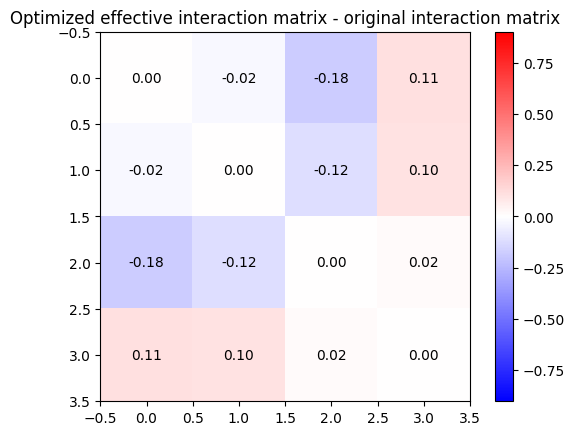

TypeError: 'Figure' object is not subscriptable

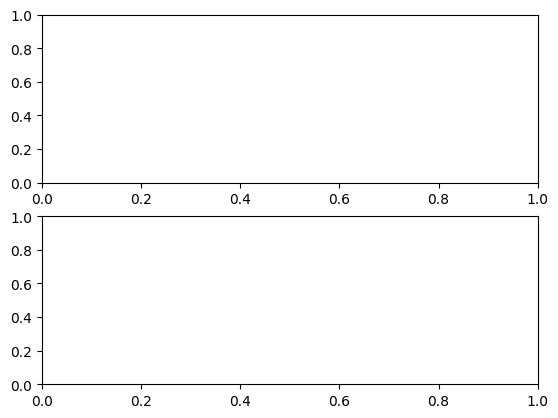

In [68]:
from src.interaction_utils import EffectiveInteractionOptimizer

OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=nqubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(nqubits):
    for j in range(nqubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()
ax, fig = plt.subplots(2, 1)

ax[0].imshow(
    OptimalFieldBe6.reconstructed(d_opt),
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(nqubits):
    for j in range(nqubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
ax[0].colorbar()
ax[0].title("Optimized effective interaction matrix ")

ax[1].imshow(
    g_matrix, cmap="bwr", vmin=-np.max(np.abs(g_matrix)), vmax=np.max(np.abs(g_matrix))
)
for i in range(nqubits):
    for j in range(nqubits):
        plt.text(j, i, f"{g_matrix[i,j]:.2f}", ha="center", va="center", color="black")
ax[1].colorbar()
ax[1].title("one-quasiparticle interaction matrix ")
plt.show()

Corresponding XY model

In [69]:
hamiltonian_xy = 0.0
for i in range(nqubits):
    for j in range(i + 1, nqubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=nqubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=nqubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0

for i in range(nqubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=nqubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [70]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [71]:
print("Eigenvalues of the NSM quasiparticle Hamiltonian:")
print(eigenvalues_nsm)

Eigenvalues of the NSM quasiparticle Hamiltonian:
[-35.4287     -29.06355605 -26.05541424 -25.75024078 -25.41688892
 -20.91568524 -18.30197974 -17.91852234 -17.1145297  -16.34627607
 -15.68910691 -11.19859406  -8.8521      -8.0583      -7.31970594
   0.        ]


In [72]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=nqubits).qutip_op
    for i in range(nqubits)
)
print(N_op.shape)
basis = computational_basis(nqubits)
# shape (2**nqubits, nqubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(16, 16)
Ground state energy in N=1 sector: -11.198594055006485
Ground state in N=1 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
        0001    0.20299    0.45055    0.00000
        0010    0.26567    0.51543    0.00000
        0100    0.26567   -0.51543    0.00000
        1000    0.26567    0.51543    0.00000


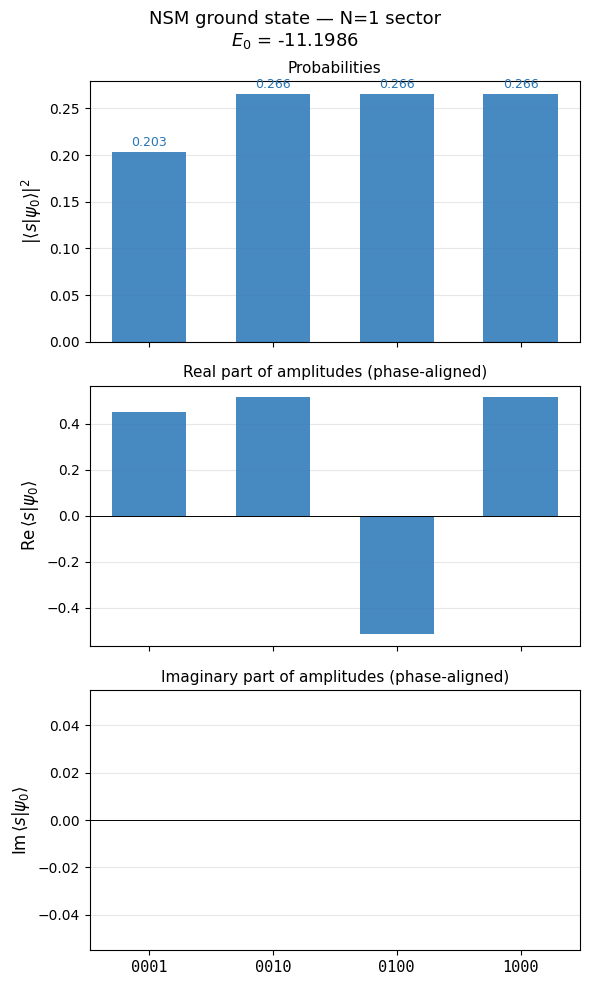

In [73]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(nqubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

In [74]:
print(eigenvalues_nsm)
gs_idx = np.argmin(np.abs(eigenvalues_nsm - ground_eigenvalue_N1))
print(eigenstates_nsm[gs_idx].full())
print(gs_idx)

[-35.4287     -29.06355605 -26.05541424 -25.75024078 -25.41688892
 -20.91568524 -18.30197974 -17.91852234 -17.1145297  -16.34627607
 -15.68910691 -11.19859406  -8.8521      -8.0583      -7.31970594
   0.        ]
[[ 0.        +0.j]
 [ 0.45054942+0.j]
 [ 0.51543031+0.j]
 [ 0.        +0.j]
 [-0.51543031+0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.51543031+0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]]
11


The gadget

In [75]:
from qutip import identity

physical_field = np.zeros(physical_qubits)
physical_field[:nqubits] = diagonal_elements / (gamma)
hamiltonian_z = 0.0
for i in range(0, physical_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[gamma * (1 - 2) + physical_field[i]],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

couples = [(0, 1), (0, 4), (1, 4), (2, 3), (2, 5), (3, 5)]

for i in range(nqubits, physical_qubits):
    for j in range(i + 1, physical_qubits):

        hamiltonian_z += SpinOperator(
            [("z", i, "z", j)],
            coupling=[delta2],
            size=physical_qubits,
            verbose=1,
        ).qutip_op
    print(hamiltonian_z)
hamiltonian_zz = 0.0
for i, j in couples:
    print(
        f"Adding coupling between qubits {i} and {j} with strength {2 * gamma * jij[i, j]}"
    )
    hamiltonian_zz += SpinOperator(
        [("qz", i, "qz", j)],
        coupling=[2 * gamma * jij[i, j]],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

print(hamiltonian_zz.diag())
longitudinal_hamiltonian = (
    hamiltonian_z
    + hamiltonian_zz
    + (2 * gamma + delta2) * qt.tensor([qt.qeye(2)] * physical_qubits)
)
print(longitudinal_hamiltonian.diag())
basis_physicalqubits = computational_basis(physical_qubits)

Quantum object: dims=[[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape=(64, 64), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 10.        0.        0.      ...   0.        0.        0.     ]
 [  0.      -20.        0.      ...   0.        0.        0.     ]
 [  0.        0.      -20.      ...   0.        0.        0.     ]
 ...
 [  0.        0.        0.      ... -63.54287   0.        0.     ]
 [  0.        0.        0.      ...   0.      -63.54287   0.     ]
 [  0.        0.        0.      ...   0.        0.      -53.54287]]
Quantum object: dims=[[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape=(64, 64), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 10.        0.        0.      ...   0.        0.        0.     ]
 [  0.      -20.        0.      ...   0.        0.        0.     ]
 [  0.        0.      -20.      ...   0.        0.        0.     ]
 ...
 [  0.        0.        0.      ... -63.54287   0.        0.     ]
 [  0.        0.        0.      ...   0.      -63.54287   0.     

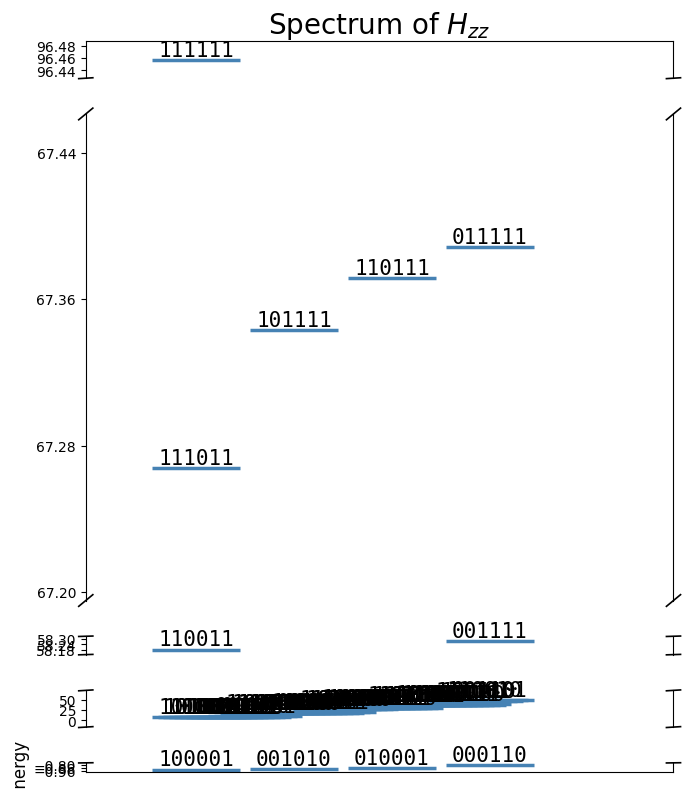

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from src.utils import computational_basis


def plot_spectrum(energies, basis, gap_threshold=0.3, figsize=(7, 8)):
    """
    Plot energy spectrum with broken axis to show both small splittings
    and large gaps between subspaces.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    gap_threshold : float
        Fraction of max gap used to detect subspace boundaries.
    figsize : tuple
    """
    energies = np.real(np.array(energies))

    assert len(energies) == len(basis), (
        f"Size mismatch: energies has {len(energies)} entries "
        f"but basis has {len(basis)} rows."
    )

    labels = ["".join(map(str, row)) for row in basis]
    order = np.argsort(energies)
    sorted_energies = energies[order]
    sorted_labels = [labels[i] for i in order]

    # --- detect subspaces from large gaps ---
    gaps = np.diff(sorted_energies)
    max_gap = gaps.max()
    boundaries = np.where(gaps > gap_threshold * max_gap)[0]
    splits = np.split(np.arange(len(sorted_energies)), boundaries + 1)

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": heights},
        squeeze=False,
    )
    axes = axes.flatten()
    splits = splits[::-1]  # highest energy at top

    for ax, group in zip(axes, splits):
        es = sorted_energies[group]
        ls = [sorted_labels[i] for i in group]
        n = len(es)

        x_positions = np.linspace(0.15, 0.55, max(n, 1))

        for x, e, label in zip(x_positions, es, ls):
            ax.hlines(e, x - 0.06, x + 0.06, linewidth=2.5, color="steelblue")
            ax.text(
                x,
                e,
                label,
                va="bottom",
                ha="center",
                fontsize=15,
                fontfamily="monospace",
            )

        span = es.max() - es.min()
        margin = max(span * 0.6, 0.03)
        ax.set_ylim(es.min() - margin, es.max() + margin)
        ax.set_xlim(0, 0.8)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines["top"].set_visible(False)

    # break marks between panels
    d = 0.012
    for ax_bot, ax_top in zip(axes[1:], axes[:-1]):
        for ax, y in [(ax_bot, 1), (ax_top, 0)]:
            kw = dict(color="k", clip_on=False, linewidth=1.2, transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    # label and format all axes uniformly
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    for ax in axes:
        ax.yaxis.set_major_formatter(formatter)

    axes[-1].set_ylabel("Energy", fontsize=12)  # bottom panel gets y-label
    axes[0].set_title(r"Spectrum of $H_{zz}$", fontsize=20)

    plt.tight_layout()
    plt.show()


full_basis = computational_basis(physical_qubits)

plot_spectrum(longitudinal_hamiltonian.diag(), full_basis)

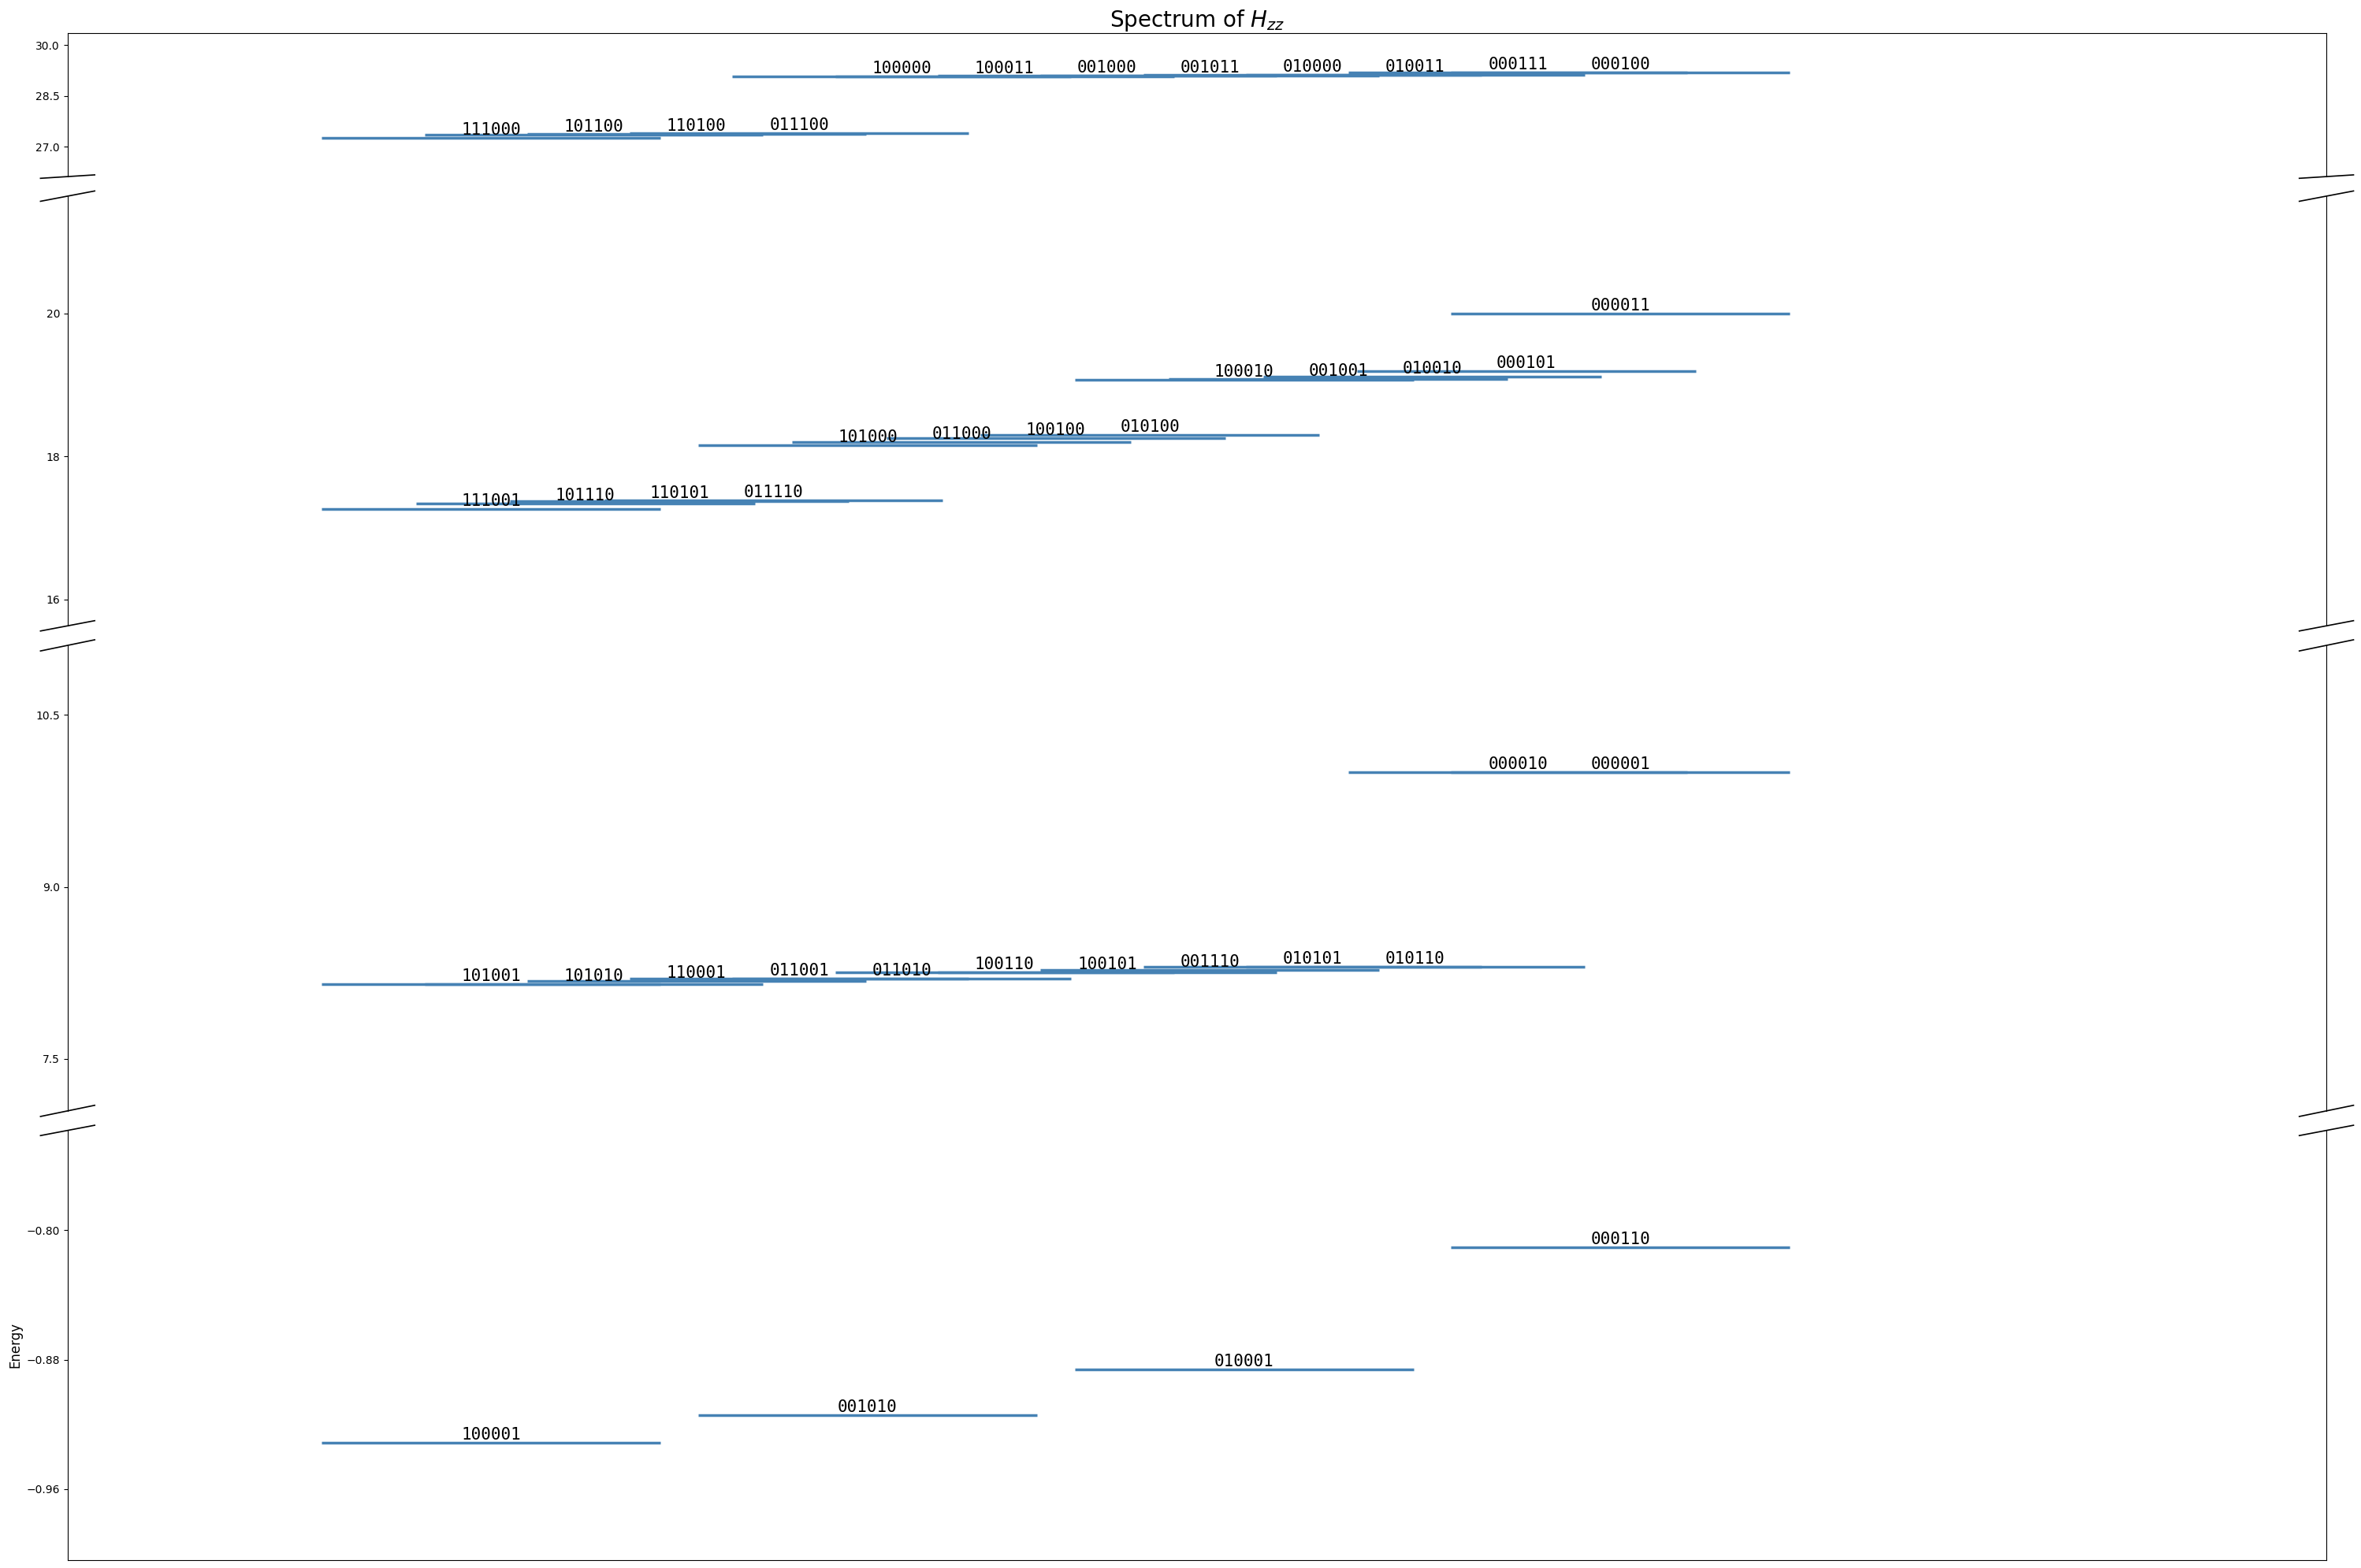

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from src.utils import computational_basis


def plot_spectrum(energies, basis, gap_threshold=0.3, figsize=(7, 8), ylim=None):
    """
    Plot energy spectrum with broken axis to show both small splittings
    and large gaps between subspaces.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    gap_threshold : float
        Fraction of max gap used to detect subspace boundaries.
    figsize : tuple
    ylim : tuple (emin, emax) or None
        If given, only show energy levels in this range.
    """
    energies = np.real(np.array(energies))

    assert len(energies) == len(basis), (
        f"Size mismatch: energies has {len(energies)} entries "
        f"but basis has {len(basis)} rows."
    )

    labels = ["".join(map(str, row)) for row in basis]
    order = np.argsort(energies)
    sorted_energies = energies[order]
    sorted_labels = [labels[i] for i in order]

    # --- optionally restrict to energy window ---
    if ylim is not None:
        emin, emax = ylim
        mask = (sorted_energies >= emin) & (sorted_energies <= emax)
        sorted_energies = sorted_energies[mask]
        sorted_labels = [l for l, m in zip(sorted_labels, mask) if m]

    if len(sorted_energies) == 0:
        raise ValueError(f"No energy levels found in range {ylim}.")

    # --- detect subspaces from large gaps ---
    gaps = np.diff(sorted_energies)
    max_gap = gaps.max() if len(gaps) > 0 else 1.0
    boundaries = np.where(gaps > gap_threshold * max_gap)[0]
    splits = np.split(np.arange(len(sorted_energies)), boundaries + 1)

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": heights},
        squeeze=False,
    )
    axes = axes.flatten()
    splits = splits[::-1]  # highest energy at top

    for ax, group in zip(axes, splits):
        es = sorted_energies[group]
        ls = [sorted_labels[i] for i in group]
        n = len(es)

        x_positions = np.linspace(0.15, 0.55, max(n, 1))

        for x, e, label in zip(x_positions, es, ls):
            ax.hlines(e, x - 0.06, x + 0.06, linewidth=2.5, color="steelblue")
            ax.text(
                x,
                e,
                label,
                va="bottom",
                ha="center",
                fontsize=15,
                fontfamily="monospace",
            )

        span = es.max() - es.min()
        margin = max(span * 0.6, 0.03)
        ax.set_ylim(es.min() - margin, es.max() + margin)
        ax.set_xlim(0, 0.8)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines["top"].set_visible(False)

    # break marks between panels
    d = 0.012
    for ax_bot, ax_top in zip(axes[1:], axes[:-1]):
        for ax, y in [(ax_bot, 1), (ax_top, 0)]:
            kw = dict(color="k", clip_on=False, linewidth=1.2, transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    # label and format all axes uniformly
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    for ax in axes:
        ax.yaxis.set_major_formatter(formatter)

    axes[-1].set_ylabel("Energy", fontsize=12)
    axes[0].set_title(r"Spectrum of $H_{zz}$", fontsize=20)

    plt.tight_layout()
    plt.show()


# --- usage ---
full_basis = computational_basis(physical_qubits)

# show only levels between -1 and 2
plot_spectrum(
    longitudinal_hamiltonian.diag(), full_basis, ylim=(-30, 30), figsize=(30, 20)
)

In [79]:
transverse_hamiltonian = 0.0

for i in range(0, nqubits):
    print(f"Adding transverse field on qubit {i} with strength {d_opt[i] }")
    transverse_hamiltonian += SpinOperator(
        [("x", i)],
        coupling=[d_opt[i] / np.sqrt(2)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

for j in range(nqubits, physical_qubits):
    print(f"Adding transverse field on qubit {j} with strength {delta2}")
    transverse_hamiltonian += SpinOperator(
        [("x", j)],
        coupling=[delta2 / np.sqrt(2)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op


total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian

eigenvalues, eigenstates = total_hamiltonian.eigenstates()

print((eigenvalues))

Adding transverse field on qubit 0 with strength -0.7233974438566328
Adding transverse field on qubit 1 with strength 0.9192361047104399
Adding transverse field on qubit 2 with strength -0.8074361803652613
Adding transverse field on qubit 3 with strength -1.0924272668172694
Adding transverse field on qubit 4 with strength 10
Adding transverse field on qubit 5 with strength 10
[-4.76999663e+00 -4.52162532e+00 -4.47735137e+00 -4.38145581e+00
  1.07700425e-02  9.02655328e-02  1.66896868e-01  2.40727663e-01
  1.98876052e+00  5.48681777e+00  5.63398742e+00  7.94490828e+00
  8.06654166e+00  8.12469968e+00  8.24514562e+00  9.82544238e+00
  1.22709254e+01  1.23696495e+01  1.24353023e+01  1.24655387e+01
  1.44325279e+01  1.44916809e+01  1.45254303e+01  1.47835812e+01
  2.25381646e+01  2.27087329e+01  2.27752097e+01  2.29422403e+01
  2.44577111e+01  2.71406811e+01  2.72932933e+01  2.74033690e+01
  2.74651223e+01  2.90500671e+01  2.91529947e+01  2.91851896e+01
  2.93937219e+01  3.00964507e+01  3.

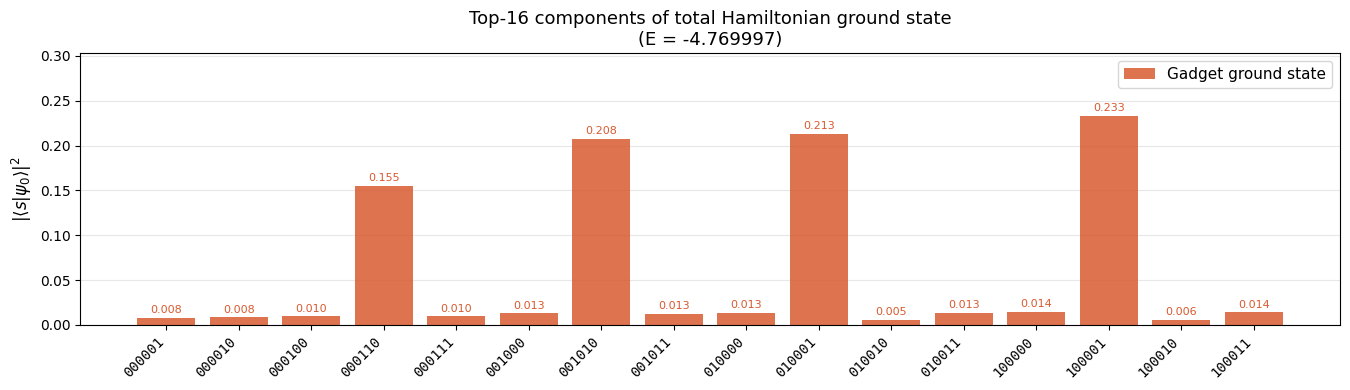

Quantum object: dims=[[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape=(64, 64), type='oper', dtype=CSR, isherm=True
Qobj data =
[[40.          7.07106781  7.07106781 ...  0.          0.
   0.        ]
 [ 7.07106781 10.          0.         ...  0.          0.
   0.        ]
 [ 7.07106781  0.         10.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... 46.45713     0.
   7.07106781]
 [ 0.          0.          0.         ...  0.         46.45713
   7.07106781]
 [ 0.          0.          0.         ...  7.07106781  7.07106781
  96.45713   ]]


In [80]:
# ── Figure 1: wavefunction comparison — full gadget ground state ──────────────

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from src.utils import computational_basis


# ── helper (define inline in case previous cells weren't run) ─────────────────
def get_n1_ground_state(hamiltonian, n_qubits):
    """Return (ground_eigenvalue, ground_state_ket) in the N=1 sector."""
    N_op = sum(
        qt.tensor(
            [qt.qeye(2)] * i
            + [(qt.qeye(2) - qt.sigmaz()) / 2]
            + [qt.qeye(2)] * (n_qubits - i - 1)
        )
        for i in range(n_qubits)
    )
    evals, evecs = hamiltonian.eigenstates()
    sector = [
        (e, v) for e, v in zip(evals, evecs) if abs(qt.expect(N_op, v) - 1) < 1e-6
    ]
    sector.sort(key=lambda x: x[0])
    return sector[0]


def state_probs(ket, n_qubits):
    return np.abs(ket.full().flatten()) ** 2


# ── NSM ground state (physical_qubits space, N=1 sector) ─────────────────────
nsm_gs_energy, nsm_gs = get_n1_ground_state(nsm_quasiparticle_hamiltonian, nqubits)
nsm_probs = state_probs(nsm_gs, nqubits)

# ── Ground state of the full (total) Hamiltonian ──────────────────────────────
g_evals, g_evecs = total_hamiltonian.eigenstates()
gadget_gs = g_evecs[0]

gadget_gs_probs = np.abs(gadget_gs.full().flatten()) ** 2

n_total = int(np.round(np.log2(gadget_gs_probs.shape[0])))
all_labels = [format(i, f"0{n_total}b") for i in range(2**n_total)]

# ── Top-K components ──────────────────────────────────────────────────────────
TOP_K = 16
top_indices = np.argsort(gadget_gs_probs)[::-1][:TOP_K]
top_labels = [all_labels[i] for i in top_indices]
top_gadget = gadget_gs_probs[top_indices]

order = np.argsort(top_labels)
top_labels = [top_labels[i] for i in order]
top_gadget = top_gadget[order]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(max(8, len(top_labels) * 0.85), 4))

bars_gad = ax1.bar(
    range(len(top_labels)),
    top_gadget,
    color="#d85a30",
    alpha=0.85,
    label="Gadget ground state",
)

ax1.set_xticks(range(len(top_labels)))
ax1.set_xticklabels(
    top_labels, fontfamily="monospace", fontsize=10, rotation=45, ha="right"
)
ax1.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax1.set_title(
    f"Top-{TOP_K} components of total Hamiltonian ground state\n"
    f"(E = {g_evals[0]:.6f})",
    fontsize=13,
)
ax1.legend(fontsize=11)
ax1.set_ylim(0, top_gadget.max() * 1.3)
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)

for bar, h in zip(bars_gad, top_gadget):
    if h > 0.005:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.003,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#d85a30",
        )

plt.tight_layout()
plt.savefig("gadget_gs_bitstrings.pdf", bbox_inches="tight")
plt.show()

print(total_hamiltonian)

NSM GS energy (N=1):     -11.198594
Gadget GS energy:         -4.769997
Fidelity (phase-aligned): 0.960877


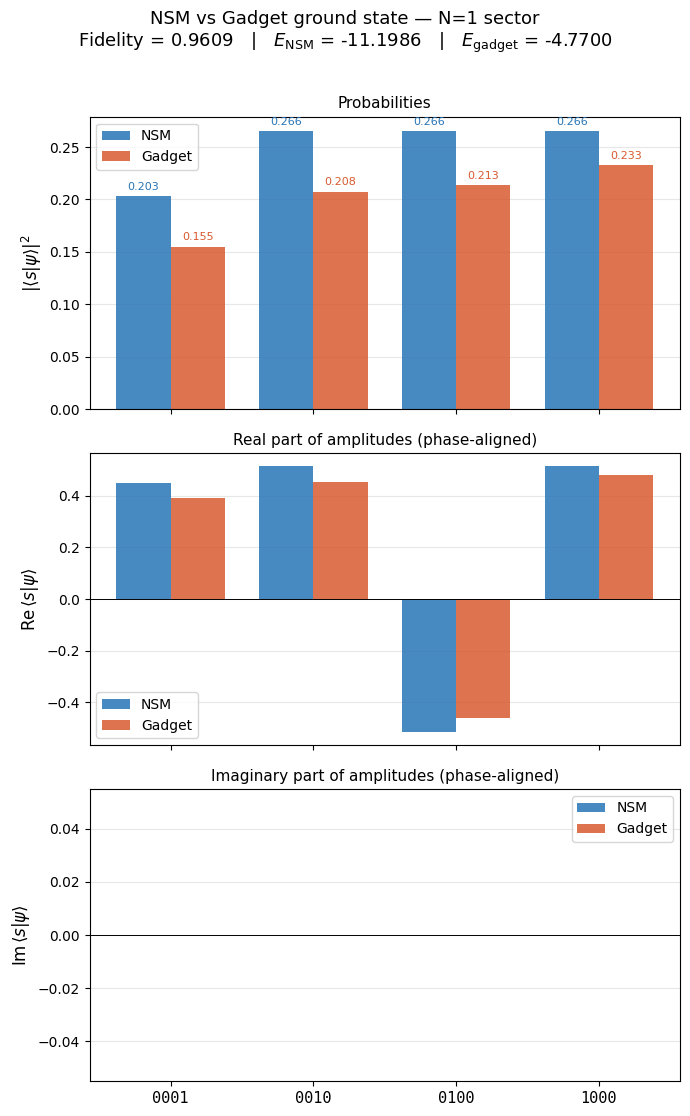

In [81]:
# ── NSM vs Gadget GS: probabilities, amplitudes, and correct fidelity ─────────
#
# Key insight: the gadget GS has the form sum_i c_i |phys_i> ⊗ |anc_i>
# where each term lives in a different ancilla sector (one-hot on ancilla).
# The correct projected state on the physical qubits is:
#   |psi_proj> = sum_i c_i_eff |phys_i>
# where c_i_eff is obtained by picking, for each physical basis state,
# the dominant ancilla sector's amplitude.
#
# Fidelity = |<nsm_gs|psi_proj>|^2  after phase-aligning both states.

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from src.utils import computational_basis

# ── helpers ───────────────────────────────────────────────────────────────────


def number_op(i, n_qubits):
    ops = [qt.qeye(2)] * n_qubits
    ops[i] = (qt.qeye(2) - qt.sigmaz()) / 2
    return qt.tensor(ops)


def total_number_op(n_qubits, sites=None):
    if sites is None:
        sites = range(n_qubits)
    return sum(number_op(i, n_qubits) for i in sites)


def get_n1_ground_state(hamiltonian, n_qubits):
    N_op = total_number_op(n_qubits)
    evals, evecs = hamiltonian.eigenstates()
    sector = [
        (e, v) for e, v in zip(evals, evecs) if abs(qt.expect(N_op, v) - 1) < 1e-6
    ]
    sector.sort(key=lambda x: x[0])
    return sector[0]


# ── 1. NSM ground state ───────────────────────────────────────────────────────
nsm_gs_energy, nsm_gs = get_n1_ground_state(nsm_quasiparticle_hamiltonian, nqubits)
nsm_amps = nsm_gs.full().flatten()  # shape (2^nqubits,), complex

# ── 2. Gadget ground state ────────────────────────────────────────────────────
g_evals, g_evecs = total_hamiltonian.eigenstates()
gadget_gs = g_evecs[0]
gadget_amps_full = gadget_gs.full().flatten()  # shape (2^n_total,), complex
n_total = int(np.round(np.log2(len(gadget_amps_full))))
n_anc = n_total - nqubits
phys_dim = 2**nqubits
anc_dim = 2**n_anc

# Reshape: [physical_index, ancilla_index]
gadget_2d = gadget_amps_full.reshape(phys_dim, anc_dim)

# ── 3. Extract projected amplitudes correctly ──────────────────────────────────
# For each physical basis state, find the ancilla sector with the largest weight
# and take that amplitude.  This handles the one-hot structure without mixing
# phases across different ancilla sectors.
anc_weights = np.abs(gadget_2d) ** 2  # (phys_dim, anc_dim)
dominant_anc = np.argmax(
    anc_weights, axis=1
)  # (phys_dim,) — dominant ancilla per physical state
projected_amps = np.array([gadget_2d[p, dominant_anc[p]] for p in range(phys_dim)])


# ── 4. Phase-align and compute fidelity ───────────────────────────────────────
# Remove global phase from each state by rotating to make the largest component real+positive
def phase_align(amps):
    idx = np.argmax(np.abs(amps))
    return amps * np.exp(-1j * np.angle(amps[idx]))


nsm_aligned = phase_align(nsm_amps)
gadget_aligned = phase_align(projected_amps)

# Fidelity as overlap of the two (normalise just in case)
nsm_norm = nsm_aligned / np.linalg.norm(nsm_aligned)
gadget_norm = gadget_aligned / np.linalg.norm(gadget_aligned)
fidelity = np.abs(np.dot(nsm_norm.conj(), gadget_norm)) ** 2

print(f"NSM GS energy (N=1):     {nsm_gs_energy:.6f}")
print(f"Gadget GS energy:         {g_evals[0]:.6f}")
print(f"Fidelity (phase-aligned): {fidelity:.6f}")

# ── 5. Select N=1 sector for plotting ─────────────────────────────────────────
basis_labels = ["".join(map(str, row)) for row in computational_basis(nqubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

nsm_probs_n1 = np.abs(nsm_aligned) ** 2
gadget_probs_n1 = np.abs(gadget_aligned) ** 2
nsm_re_n1 = nsm_aligned.real
gadget_re_n1 = gadget_aligned.real
nsm_im_n1 = nsm_aligned.imag
gadget_im_n1 = gadget_aligned.imag

nsm_probs_n1 = nsm_probs_n1[n1_mask]
gadget_probs_n1 = gadget_probs_n1[n1_mask]
nsm_re_n1 = nsm_re_n1[n1_mask]
gadget_re_n1 = gadget_re_n1[n1_mask]
nsm_im_n1 = nsm_im_n1[n1_mask]
gadget_im_n1 = gadget_im_n1[n1_mask]

x = np.arange(len(labels_n1))
width = 0.38
CLR_NSM = "#2775b6"
CLR_GAD = "#d85a30"

# ── 6. Three-panel figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(max(7, len(labels_n1) * 0.95), 11), sharex=True)
fig.suptitle(
    f"NSM vs Gadget ground state — N=1 sector\n"
    f"Fidelity = {fidelity:.4f}   |   "
    f"$E_{{\\rm NSM}}$ = {nsm_gs_energy:.4f}   |   "
    f"$E_{{\\rm gadget}}$ = {g_evals[0]:.4f}",
    fontsize=13,
    y=1.01,
)

# — Panel 1: probabilities —
ax = axes[0]
ax.bar(x - width / 2, nsm_probs_n1, width, label="NSM", color=CLR_NSM, alpha=0.85)
ax.bar(x + width / 2, gadget_probs_n1, width, label="Gadget", color=CLR_GAD, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for vals, color, offset in [
    (nsm_probs_n1, CLR_NSM, -width / 2),
    (gadget_probs_n1, CLR_GAD, +width / 2),
]:
    for i, v in enumerate(vals):
        if v > 0.01:
            ax.text(
                i + offset,
                v + 0.004,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=color,
            )

# — Panel 2: real parts of amplitudes —
ax = axes[1]
ax.bar(x - width / 2, nsm_re_n1, width, label="NSM", color=CLR_NSM, alpha=0.85)
ax.bar(x + width / 2, gadget_re_n1, width, label="Gadget", color=CLR_GAD, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"${\rm Re}\,\langle s|\psi\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# — Panel 3: imaginary parts of amplitudes —
ax = axes[2]
ax.bar(x - width / 2, nsm_im_n1, width, label="NSM", color=CLR_NSM, alpha=0.85)
ax.bar(x + width / 2, gadget_im_n1, width, label="Gadget", color=CLR_GAD, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"${\rm Im}\,\langle s|\psi\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("wavefunction_full_comparison.pdf", bbox_inches="tight")
plt.show()

NSM GS energy:    -11.198594
Gadget GS energy: -4.769997
Fidelity:         0.999595


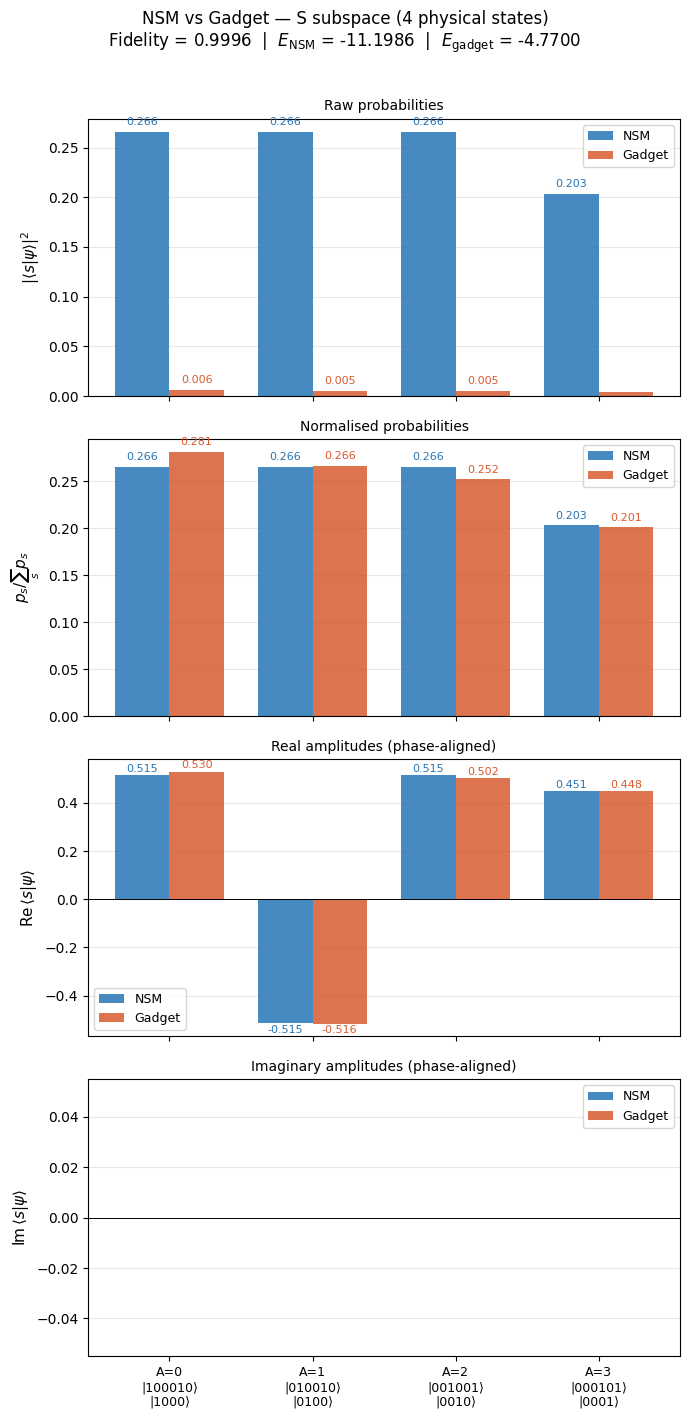


 State    NSM prob    Gad prob    NSM norm    Gad norm    NSM Re    Gad Re
------------------------------------------------------------------------
  A=0     0.26567     0.00577     0.26567     0.28110    0.5154    0.5302
  A=1     0.26567     0.00546     0.26567     0.26613   -0.5154   -0.5159
  A=2     0.26567     0.00517     0.26567     0.25196    0.5154    0.5020
  A=3     0.20299     0.00412     0.20299     0.20081    0.4505    0.4481


In [82]:
# ── Mapping: gadget 6-bit S-states → NSM 4-bit bitstrings ────────────────────
# A=0: |1,0,0,0,1,0> (outer 0, w1) → NSM |1,0,0,0>
# A=1: |0,1,0,0,1,0> (outer 1, w1) → NSM |0,1,0,0>
# A=2: |0,0,1,0,0,1> (outer 2, w2) → NSM |0,0,1,0>
# A=3: |0,0,0,1,0,1> (outer 3, w2) → NSM |0,0,0,1>

gadget_S_states = ["100010", "010010", "001001", "000101"]  # 6-bit gadget
nsm_S_states = ["1000", "0100", "0010", "0001"]  # 4-bit NSM

# ── 1. NSM amplitudes on the 4 physical states ────────────────────────────────
nsm_gs_energy, nsm_gs = get_n1_ground_state(nsm_quasiparticle_hamiltonian, nqubits)
nsm_amps_full = nsm_gs.full().flatten()

basis_nsm = ["".join(map(str, row)) for row in computational_basis(nqubits)]
nsm_amp_map = dict(zip(basis_nsm, nsm_amps_full))
nsm_amps_S = np.array([nsm_amp_map[s] for s in nsm_S_states])

# ── 2. Gadget amplitudes on the 4 S-states ────────────────────────────────────
g_evals, g_evecs = total_hamiltonian.eigenstates()
gadget_gs = g_evecs[0]
gadget_amps_full = gadget_gs.full().flatten()

basis_gadget = ["".join(map(str, row)) for row in computational_basis(physical_qubits)]
gadget_amp_map = dict(zip(basis_gadget, gadget_amps_full))
gadget_amps_S = np.array([gadget_amp_map[s] for s in gadget_S_states])


# ── 3. Phase-align both ───────────────────────────────────────────────────────
def phase_align(amps):
    idx = np.argmax(np.abs(amps))
    return amps * np.exp(-1j * np.angle(amps[idx]))


nsm_aligned = phase_align(nsm_amps_S)
gadget_aligned = phase_align(gadget_amps_S)

# Normalise
nsm_norm = nsm_aligned / np.linalg.norm(nsm_aligned)
gadget_norm = gadget_aligned / np.linalg.norm(gadget_aligned)

fidelity = np.abs(np.dot(nsm_norm.conj(), gadget_norm)) ** 2
print(f"NSM GS energy:    {nsm_gs_energy:.6f}")
print(f"Gadget GS energy: {g_evals[0]:.6f}")
print(f"Fidelity:         {fidelity:.6f}")

# ── 4. Probabilities: raw and normalised ──────────────────────────────────────
nsm_probs = np.abs(nsm_aligned) ** 2
gadget_probs = np.abs(gadget_aligned) ** 2

# Normalised to sum = 1 within the S subspace
nsm_probs_norm = nsm_probs / nsm_probs.sum()
gadget_probs_norm = gadget_probs / gadget_probs.sum()

# ── 5. Plot: 4 panels ─────────────────────────────────────────────────────────
x_labels = [
    f"A={i}\n|{g}⟩\n|{n}⟩"
    for i, (g, n) in enumerate(zip(gadget_S_states, nsm_S_states))
]
x = np.arange(4)
width = 0.38
CLR_NSM = "#2775b6"
CLR_GAD = "#d85a30"

fig, axes = plt.subplots(4, 1, figsize=(7, 14), sharex=True)
fig.suptitle(
    f"NSM vs Gadget — S subspace (4 physical states)\n"
    f"Fidelity = {fidelity:.4f}  |  "
    f"$E_\\mathrm{{NSM}}$ = {nsm_gs_energy:.4f}  |  "
    f"$E_\\mathrm{{gadget}}$ = {g_evals[0]:.4f}",
    fontsize=12,
    y=1.01,
)

panel_data = [
    (nsm_probs, gadget_probs, r"$|\langle s|\psi\rangle|^2$", "Raw probabilities"),
    (
        nsm_probs_norm,
        gadget_probs_norm,
        r"$p_s / \sum_s p_s$",
        "Normalised probabilities",
    ),
    (
        nsm_norm.real,
        gadget_norm.real,
        r"$\mathrm{Re}\,\langle s|\psi\rangle$",
        "Real amplitudes (phase-aligned)",
    ),
    (
        nsm_norm.imag,
        gadget_norm.imag,
        r"$\mathrm{Im}\,\langle s|\psi\rangle$",
        "Imaginary amplitudes (phase-aligned)",
    ),
]

for ax, (nsm_vals, gad_vals, ylabel, title) in zip(axes, panel_data):
    b1 = ax.bar(x - width / 2, nsm_vals, width, label="NSM", color=CLR_NSM, alpha=0.85)
    b2 = ax.bar(
        x + width / 2, gad_vals, width, label="Gadget", color=CLR_GAD, alpha=0.85
    )
    ax.axhline(0, color="k", linewidth=0.7)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    # Annotate bars
    for bars, color in [(b1, CLR_NSM), (b2, CLR_GAD)]:
        for bar in bars:
            h = bar.get_height()
            if abs(h) > 0.005:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.005 * np.sign(h),
                    f"{h:.3f}",
                    ha="center",
                    va="bottom" if h >= 0 else "top",
                    fontsize=8,
                    color=color,
                )

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(x_labels, fontsize=9)

plt.tight_layout()
plt.savefig("wavefunction_comparison_S_subspace.pdf", bbox_inches="tight")
plt.show()

# ── 6. Print table ────────────────────────────────────────────────────────────
print(
    f"\n{'State':>6}  {'NSM prob':>10}  {'Gad prob':>10}  {'NSM norm':>10}  {'Gad norm':>10}  {'NSM Re':>8}  {'Gad Re':>8}"
)
print("-" * 72)
for i, (g, n) in enumerate(zip(gadget_S_states, nsm_S_states)):
    print(
        f"  A={i}  {nsm_probs[i]:>10.5f}  {gadget_probs[i]:>10.5f}  "
        f"{nsm_probs_norm[i]:>10.5f}  {gadget_probs_norm[i]:>10.5f}  "
        f"{nsm_norm[i].real:>8.4f}  {gadget_norm[i].real:>8.4f}"
    )